In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#read the data
df = pd.read_csv('Dataset_Day7.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [11]:
#Replace 0 with NaN for the required columns
cols = ['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']
df[cols] = df[cols].replace(0, np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   BMI                       757 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 42.1 KB


In [12]:
#Treating missing data
numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)


df = df.fillna(median_value)
df.info()

['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
BMI                          32.3000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
m

In [13]:
for col in cols:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Outlier Detection using z-score
OutlierRows = df[
    (df["Glucose"] > 3) | (df["Glucose"] < -3) |
    (df["BloodPressure"] > 3) | (df["BloodPressure"] < -3) |
    (df["BMI"] > 3) | (df["BMI"] < -3) |
    (df["DiabetesPedigreeFunction"] > 3) | (df["DiabetesPedigreeFunction"] < -3)
]

print("% of Outlier rows in the dataset is " + str(len(OutlierRows) / len(df) * 100) + "\n")

data_OutlierFree = df.drop(OutlierRows.index, axis=0)

% of Outlier rows in the dataset is 2.734375



In [14]:
# Data Splitting into 75% training and 25% testing data

X = data_OutlierFree.drop("Outcome",axis=1)
y = data_OutlierFree["Outcome"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=1234)
len(X_train),len(X_test)

(560, 187)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Import SVM model
from sklearn import svm

kernel_values = ['linear']

#create an SVM classifier
svm_clf = svm.SVC(kernel = kernel_values[0], C = 0.1, gamma = 0.1)

# train the model
svm_clf = svm_clf.fit(X_train,y_train)

# Predict based on X_test
y_pred = svm_clf.predict(X_test)

print("Model Performance metrics are as below :-\n")
print("Accuracy is "+str(accuracy_score(y_test,y_pred)))
print("Precision is "+str(precision_score(y_test,y_pred)))
print("Recall is "+str(recall_score(y_test,y_pred)))
print("F1-Score is "+str(f1_score(y_test,y_pred)))


Model Performance metrics are as below :-

Accuracy is 0.7914438502673797
Precision is 0.7692307692307693
Recall is 0.5970149253731343
F1-Score is 0.6722689075630253


Observations:
1. Accuracy is 79.14%, which means the model will perform well overall, but may be misleading in imbalanced datasets.

2. Precision is 76.92%, which indicates there were lesser false positives.

3. Recall is 59.70%, which is moderate, this means about 40% of actual positives are being missed.

4. F1-Score is 67.23% which means Precision and Recall are decently balanced.

In [17]:
kernel_values = ['linear', 'rbf', 'sigmoid'] ## research on other kernels as HW
C_values = np.arange(0.01,0.5,0.01)
gamma_values = [0.1,1/len(X)]

PerfData = pd.DataFrame(columns = ['Kernel Type', 'Regularization', 'Gamma', 'Precision', 'Recall', 'F1-Score'])

for k in kernel_values:
    for c in C_values:
        for g in gamma_values:
            print(k+" "+str(c)+" "+str(g))
            svm_clf = svm.SVC(kernel = k, C = c, gamma = g)
            svm_clf = svm_clf.fit(X_train, y_train)
            y_pred = svm_clf.predict(X_test)

            rows = [[k, c, g, precision_score(y_test, y_pred, zero_division=0), recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]]


        PerfData = pd.concat([PerfData, pd.DataFrame(rows, columns=['Kernel Type', 'Regularization', 'Gamma', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)

display(PerfData[PerfData['F1-Score'] == max(PerfData['F1-Score'])])

linear 0.01 0.1
linear 0.01 0.0013386880856760374
linear 0.02 0.1
linear 0.02 0.0013386880856760374
linear 0.03 0.1
linear 0.03 0.0013386880856760374


C:\Users\archi\AppData\Local\Temp\ipykernel_25200\1438386662.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PerfData = pd.concat([PerfData, pd.DataFrame(rows, columns=['Kernel Type', 'Regularization', 'Gamma', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)


linear 0.04 0.1
linear 0.04 0.0013386880856760374
linear 0.05 0.1
linear 0.05 0.0013386880856760374
linear 0.060000000000000005 0.1
linear 0.060000000000000005 0.0013386880856760374
linear 0.06999999999999999 0.1
linear 0.06999999999999999 0.0013386880856760374
linear 0.08 0.1
linear 0.08 0.0013386880856760374
linear 0.09 0.1
linear 0.09 0.0013386880856760374
linear 0.09999999999999999 0.1
linear 0.09999999999999999 0.0013386880856760374
linear 0.11 0.1
linear 0.11 0.0013386880856760374
linear 0.12 0.1
linear 0.12 0.0013386880856760374
linear 0.13 0.1
linear 0.13 0.0013386880856760374
linear 0.14 0.1
linear 0.14 0.0013386880856760374
linear 0.15000000000000002 0.1
linear 0.15000000000000002 0.0013386880856760374
linear 0.16 0.1
linear 0.16 0.0013386880856760374
linear 0.17 0.1
linear 0.17 0.0013386880856760374
linear 0.18000000000000002 0.1
linear 0.18000000000000002 0.0013386880856760374
linear 0.19 0.1
linear 0.19 0.0013386880856760374
linear 0.2 0.1
linear 0.2 0.0013386880856760374


,Kernel Type,Regularization,Gamma,Precision,Recall,F1-Score
1,linear,0.02,0.001339,0.773585,0.61194,0.683333


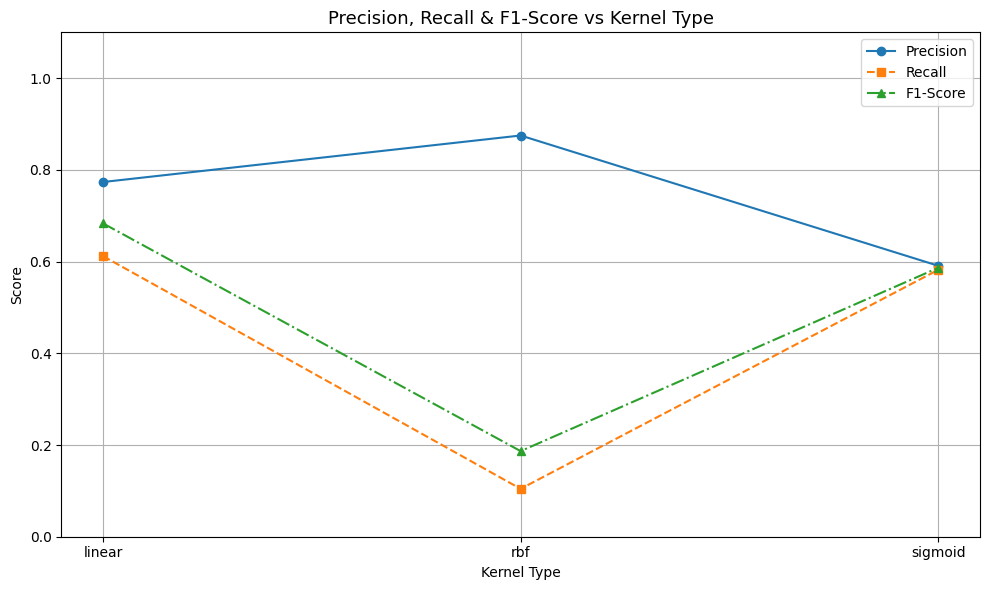


Kernel Type with Highest F1-Score:
Kernel: linear
F1-Score: 0.6833
Precision: 0.7736
Recall: 0.6119
Best C: 0.02, Best Gamma: 0.0013386880856760374


In [18]:
best_per_kernel = PerfData.loc[PerfData.groupby("Kernel Type")["F1-Score"].idxmax()]

plt.figure(figsize=(10, 6))

# X-axis labels (kernel types)
kernels = best_per_kernel["Kernel Type"]

# Y-axis values for each metric
precision = best_per_kernel["Precision"]
recall = best_per_kernel["Recall"]
f1 = best_per_kernel["F1-Score"]

plt.plot(kernels, precision, marker='o', linestyle='-', label='Precision')
plt.plot(kernels, recall, marker='s', linestyle='--', label='Recall')
plt.plot(kernels, f1, marker='^', linestyle='-.', label='F1-Score')


plt.title('Precision, Recall & F1-Score vs Kernel Type', fontsize=13)
plt.xlabel('Kernel Type')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 3: Now print the kernel with the highest F1-Score
best_row = best_per_kernel.loc[best_per_kernel["F1-Score"].idxmax()]
print("\nKernel Type with Highest F1-Score:")
print(f"Kernel: {best_row['Kernel Type']}")
print(f"F1-Score: {best_row['F1-Score']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"Best C: {best_row['Regularization']}, Best Gamma: {best_row['Gamma']}")


Observations:-

The Linear Kernel gives the highest F1-Score of approximately 0.6833.
It also has the highest precision (0.7736), though the recall is lower at 0.6119.
The RBF kernel performs the worst in terms of both recall and F1-Score.
The Sigmoid kernel gives a balanced performance but still underperforms compared to the linear kernel.

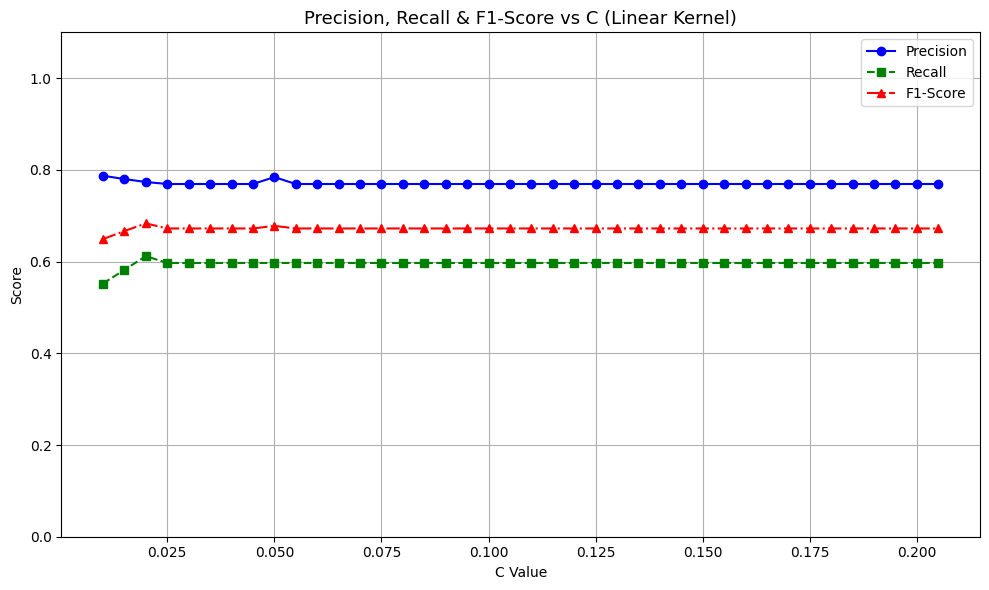


 Best C Value: 0.019999999999999997
F1-Score: 0.6833
Precision: 0.7736
Recall: 0.6119


In [19]:
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


C_values = np.arange(0.01, 0.21, 0.005)

precision_list = []
recall_list = []
f1_list = []

for c in C_values:
    svm_clf = SVC(kernel='linear', C=c)
    svm_clf.fit(X_train, y_train)
    y_pred = svm_clf.predict(X_test)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(C_values, precision_list, 'b-o', label='Precision')
plt.plot(C_values, recall_list, 'g--s', label='Recall')
plt.plot(C_values, f1_list, 'r-.^', label='F1-Score')

plt.title('Precision, Recall & F1-Score vs C (Linear Kernel)', fontsize=13)
plt.xlabel('C Value')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

best_idx = np.argmax(f1_list)
best_c = C_values[best_idx]
print(f"\n Best C Value: {best_c}")
print(f"F1-Score: {f1_list[best_idx]:.4f}")
print(f"Precision: {precision_list[best_idx]:.4f}")
print(f"Recall: {recall_list[best_idx]:.4f}")


Observations:-

The optimal C value is ~0.02, where the F1-Score peaks.
As C increases beyond 0.02, performance (F1-Score and Recall) flattens and even slightly dips.
Precision remains relatively high and stable across all C values, showing that the model is consistently good at avoiding false positives.
Recall is more sensitive to C, indicating a trade-off between margin size and misclassification penalties.